In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

In [2]:
path_file = 'data/uber_data.csv'

def load_gojek_data(file_path: str) -> pd.DataFrame:
    """
    Load Gojek data from a CSV file."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"The file {file_path} does not exist.")
    return pd.read_csv(file_path)


In [3]:
pd.set_option('display.max_columns', None)
df = load_gojek_data('../../database/uber/raw/uber_data.csv')
df

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-11-11,19:34:01,"""CNR6500631""",Completed,"""CID4337371""",Go Mini,MG Road,Ghitorni,10.2,44.4,NaN,NaN,NaN,NaN,NaN,NaN,475.0,40.08,3.7,4.1,Uber Wallet
149996,2024-11-24,15:55:09,"""CNR2468611""",Completed,"""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.1,30.8,NaN,NaN,NaN,NaN,NaN,NaN,1093.0,21.31,4.8,5.0,UPI
149997,2024-09-18,10:55:15,"""CNR6358306""",Completed,"""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,NaN,NaN,NaN,NaN,NaN,NaN,852.0,15.93,3.9,4.4,Cash
149998,2024-10-05,07:53:34,"""CNR3030099""",Completed,"""CID9415487""",Auto,Ghaziabad,Saidulajab,6.9,39.6,NaN,NaN,NaN,NaN,NaN,NaN,333.0,45.54,4.1,3.7,UPI


In [4]:
df['Incomplete Rides Reason'].value_counts()

Incomplete Rides Reason
Customer Demand      3040
Vehicle Breakdown    3012
Other Issue          2948
Name: count, dtype: int64

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [23]:
df.isnull().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

In [24]:
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [25]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Time'] = pd.to_datetime(df['Time'], errors='coerce').dt.time

## Data visualization before data cleaning (to get data correlation)

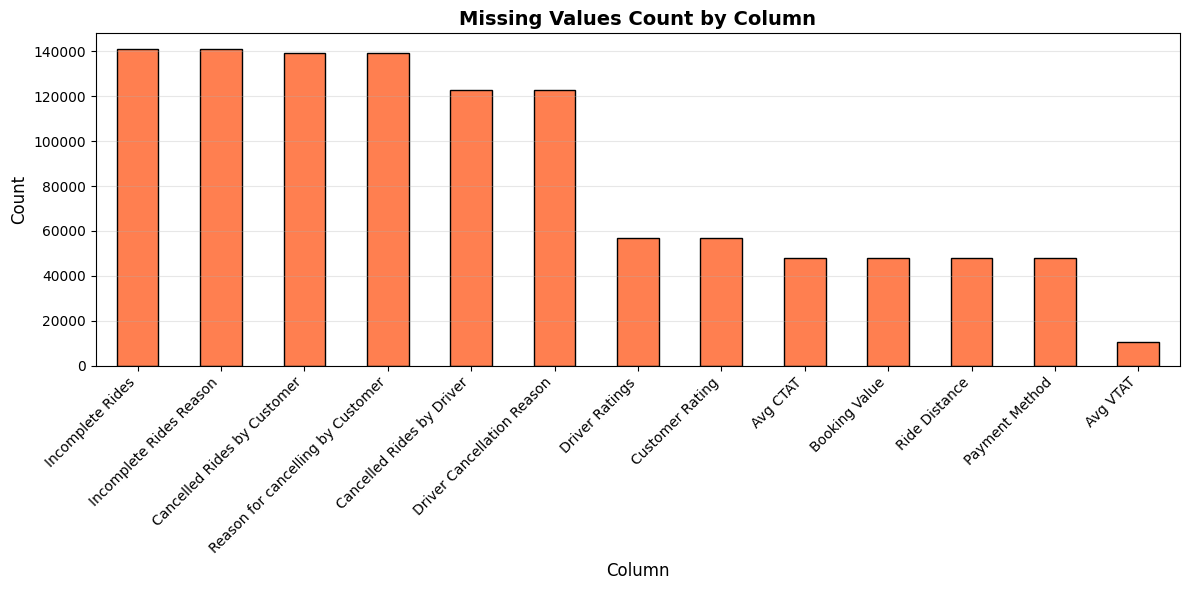

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Bar chart - Missing values count
fig, ax = plt.subplots(figsize=(12, 6))
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)
missing_counts.plot(kind='bar', ax=ax, color='coral', edgecolor='black')
plt.title('Missing Values Count by Column', fontsize=14, fontweight='bold')
plt.xlabel('Column', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
# Classify missing values: Data-Driven
def classify_missing_values(df):
    """
    Classify each column's missing values:
    - Data-Driven: Missing values follow patterns (conditional on other variables)
    - Random: No clear pattern (likely data corruption)
    - Acceptable: < 5% missing
    """
    classifications = []

    for col in df.columns:
        missing_pct = df[col].isnull().sum() / len(df) * 100
        missing_count = df[col].isnull().sum()

        if missing_count == 0:
            status = "Complete"
        elif missing_pct < 5:
            status = "Acceptable"
        else:
            # Check if missing pattern is correlated with another column
            is_missing = df[col].isnull().astype(int)

            # High variance in missing pattern = Data-Driven
            missing_variance = is_missing.var()

            if missing_variance > 0.1:  # Strong pattern
                status = "Data-Driven"
            else:
                status = "Potentially Corrupted"

            classifications.append({
                "Column": col,
                "Missing Count": missing_count,
                "Missing Percentage": round(missing_pct, 2),
                "Classification": status,
                "Action": 'Keep' if status in ['Complete', 'Data-Driven', 'Acceptable'] else 'Investigate/Remove'
            })

    return pd.DataFrame(classifications)

classification_df = classify_missing_values(df)
print("\n" + "=" * 60)
print("MISSING VALUES CLASSIFICATION")
print("=" * 60)
print(classification_df.to_string(index=False))


MISSING VALUES CLASSIFICATION
                           Column  Missing Count  Missing Percentage        Classification             Action
                         Avg VTAT          10500                 7.0 Potentially Corrupted Investigate/Remove
                         Avg CTAT          48000                32.0           Data-Driven               Keep
      Cancelled Rides by Customer         139500                93.0 Potentially Corrupted Investigate/Remove
Reason for cancelling by Customer         139500                93.0 Potentially Corrupted Investigate/Remove
        Cancelled Rides by Driver         123000                82.0           Data-Driven               Keep
       Driver Cancellation Reason         123000                82.0           Data-Driven               Keep
                 Incomplete Rides         141000                94.0 Potentially Corrupted Investigate/Remove
          Incomplete Rides Reason         141000                94.0 Potentially Corrupte

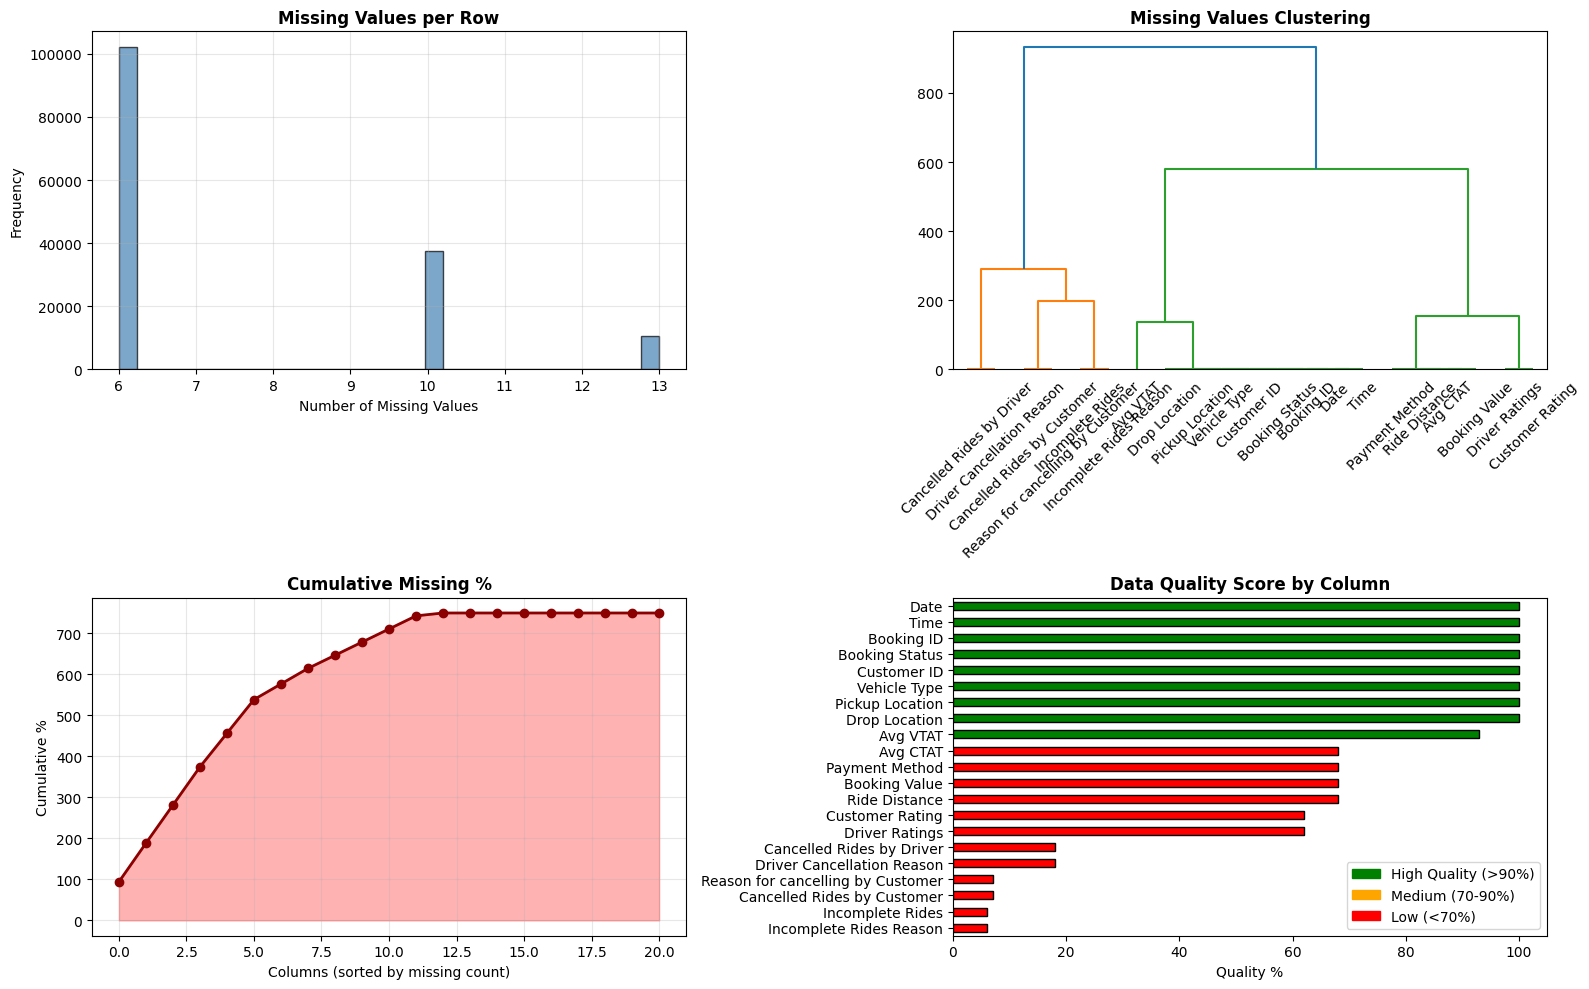

In [28]:
# 7. Visualize Missing Data Patterns
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Missing Data Pattern by Row
ax = axes[0, 0]
missing_per_row = df.isnull().sum(axis=1)
ax.hist(missing_per_row, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_title('Missing Values per Row', fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Missing Values')
ax.set_ylabel('Frequency')
ax.grid(alpha=0.3)

# Plot 2: Dendrogram of Missing Values (which columns are missing together)
from scipy.cluster.hierarchy import dendrogram, linkage
ax = axes[0, 1]
missing_matrix = df.isnull().T
if missing_matrix.shape[0] > 1:
    linkage_matrix = linkage(missing_matrix, method='ward')
    dendrogram(linkage_matrix, labels=missing_matrix.index, ax=ax, leaf_rotation=45)
    ax.set_title('Missing Values Clustering', fontsize=12, fontweight='bold')

# Plot 3: Cumulative Missing % by Column
ax = axes[1, 0]
missing_cumsum = (df.isnull().sum().sort_values(ascending=False) / len(df) * 100).cumsum()
ax.plot(missing_cumsum.values, marker='o', linewidth=2, markersize=6, color='darkred')
ax.fill_between(range(len(missing_cumsum)), missing_cumsum.values, alpha=0.3, color='red')
ax.set_title('Cumulative Missing %', fontsize=12, fontweight='bold')
ax.set_xlabel('Columns (sorted by missing count)')
ax.set_ylabel('Cumulative %')
ax.grid(alpha=0.3)

# Plot 4: Data Quality Score
ax = axes[1, 1]
quality_score = (1 - df.isnull().sum() / len(df)) * 100
quality_score = quality_score.sort_values()
colors = ['green' if x > 90 else 'orange' if x > 70 else 'red' for x in quality_score.values]
quality_score.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.set_title('Data Quality Score by Column', fontsize=12, fontweight='bold')
ax.set_xlabel('Quality %')
ax.set_xlim(0, 105)

# Add legend
green_patch = mpatches.Patch(color='green', label='High Quality (>90%)')
orange_patch = mpatches.Patch(color='orange', label='Medium (70-90%)')
red_patch = mpatches.Patch(color='red', label='Low (<70%)')
ax.legend(handles=[green_patch, orange_patch, red_patch], loc='lower right')

plt.tight_layout()
plt.show()

In [29]:
df = df.fillna({
    'Driver Cancellation Reason': 'No Reason Provided',
    'Reason for cancelling by Customer': 'No Reason Provided',
    'Cancelled Rides by Driver': 'No Reason Provided',
    'Cancelled Rides by Customer': 'No Reason Provided',
    'Incomplete Rides': 0,
    'Incomplete Rides Reason': 'No Reason Provided',
    'Booking Value': df['Booking Value'].median(),
    'Ride Distance': df['Ride Distance'].median(),
    'Driver Ratings': df['Driver Ratings'].median(),
    'Customer Rating': df['Customer Rating'].median(),
    'Payment Method': 'Debit Card',
    'Avg VTAT': df['Avg VTAT'].median(),
    'Avg CTAT': df['Avg CTAT'].median()
})
df.isnull().sum()

Date                                 0
Time                                 0
Booking ID                           0
Booking Status                       0
Customer ID                          0
Vehicle Type                         0
Pickup Location                      0
Drop Location                        0
Avg VTAT                             0
Avg CTAT                             0
Cancelled Rides by Customer          0
Reason for cancelling by Customer    0
Cancelled Rides by Driver            0
Driver Cancellation Reason           0
Incomplete Rides                     0
Incomplete Rides Reason              0
Booking Value                        0
Ride Distance                        0
Driver Ratings                       0
Customer Rating                      0
Payment Method                       0
dtype: int64

In [30]:
def clean_booking_value(df, col='Booking Value', quantile=0.85, scale=1000):
    """
    Clean and scaling the Booking Value column.
    - only values below the specified quantile are retained
    - outlier value (>= quantile) are replaced with the median value
    """

    upper = df[col].quantile(quantile)
    mask = df[col] < upper
    df = df.copy()
    # scale the booking value
    df.loc[mask, col] = df.loc[mask, col] * scale
    
    return df

In [31]:
df = clean_booking_value(df)
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,8.3,28.8,No Reason Provided,No Reason Provided,No Reason Provided,No Reason Provided,0.0,No Reason Provided,414000.0,23.72,4.3,4.5,Debit Card
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,No Reason Provided,No Reason Provided,No Reason Provided,No Reason Provided,1.0,Vehicle Breakdown,237000.0,5.73,4.3,4.5,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,No Reason Provided,No Reason Provided,No Reason Provided,No Reason Provided,0.0,No Reason Provided,627000.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,No Reason Provided,No Reason Provided,No Reason Provided,No Reason Provided,0.0,No Reason Provided,416000.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,No Reason Provided,No Reason Provided,No Reason Provided,No Reason Provided,0.0,No Reason Provided,737.0,48.21,4.1,4.3,UPI


In [32]:
df['Incomplete Rides'].value_counts()

Incomplete Rides
0.0    141000
1.0      9000
Name: count, dtype: int64

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   Date                               150000 non-null  datetime64[ns]
 1   Time                               150000 non-null  object        
 2   Booking ID                         150000 non-null  object        
 3   Booking Status                     150000 non-null  object        
 4   Customer ID                        150000 non-null  object        
 5   Vehicle Type                       150000 non-null  object        
 6   Pickup Location                    150000 non-null  object        
 7   Drop Location                      150000 non-null  object        
 8   Avg VTAT                           150000 non-null  float64       
 9   Avg CTAT                           150000 non-null  float64       
 10  Cancelled Rides by C

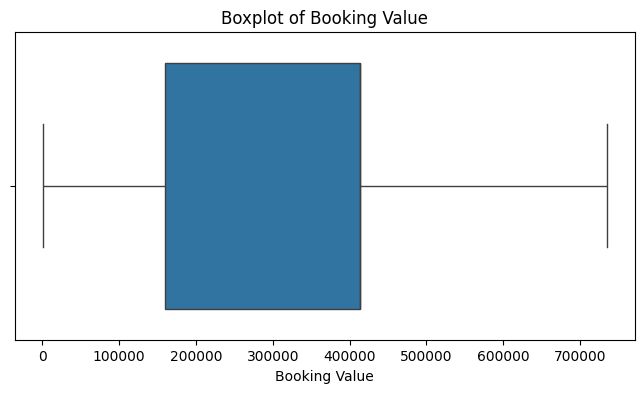

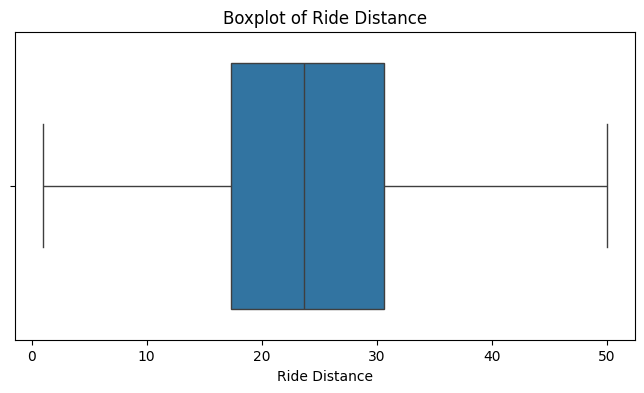

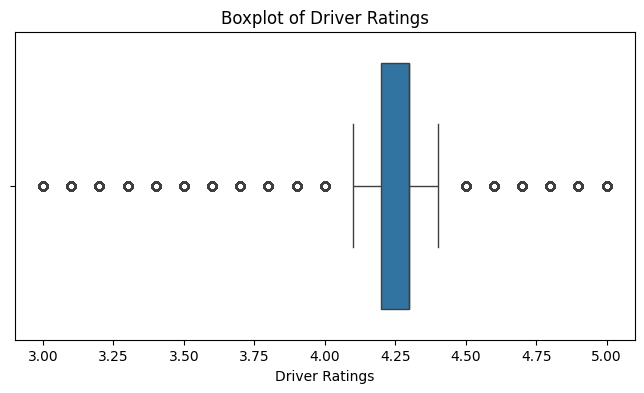

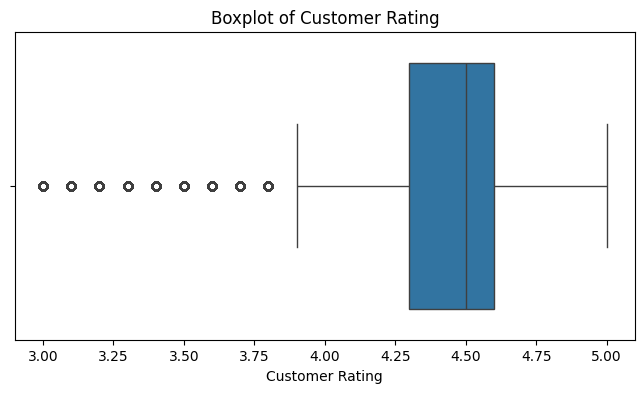

KeyboardInterrupt: 

In [34]:
# check outliers in Booking Value
numeric_cols = ['Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating', 'Avg VTAT', 'Avg CTAT']
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

Data Visualization

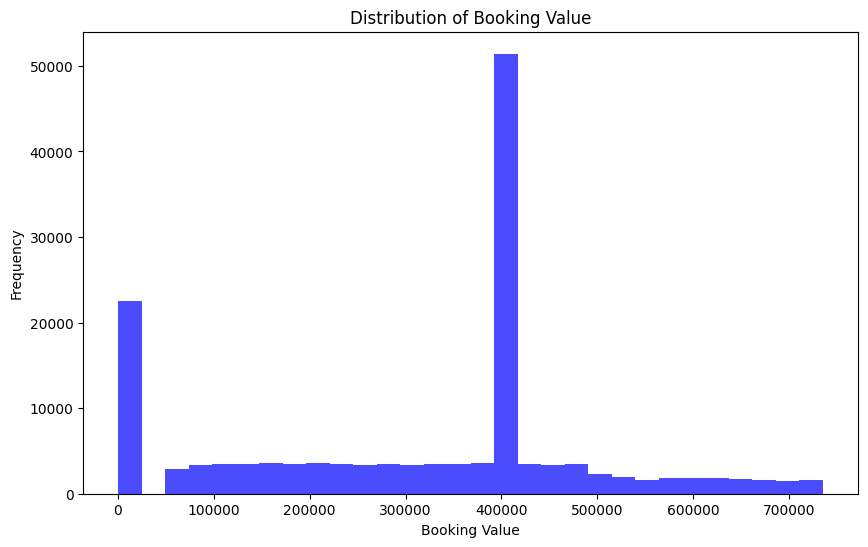

In [ ]:
# create visualization for gojek dataset

plt.figure(figsize=(10, 6))
plt.hist(df['Booking Value'], bins=30, color='blue', alpha=0.7)
plt.title('Distribution of Booking Value')
plt.xlabel('Booking Value')
plt.ylabel('Frequency')
plt.show()

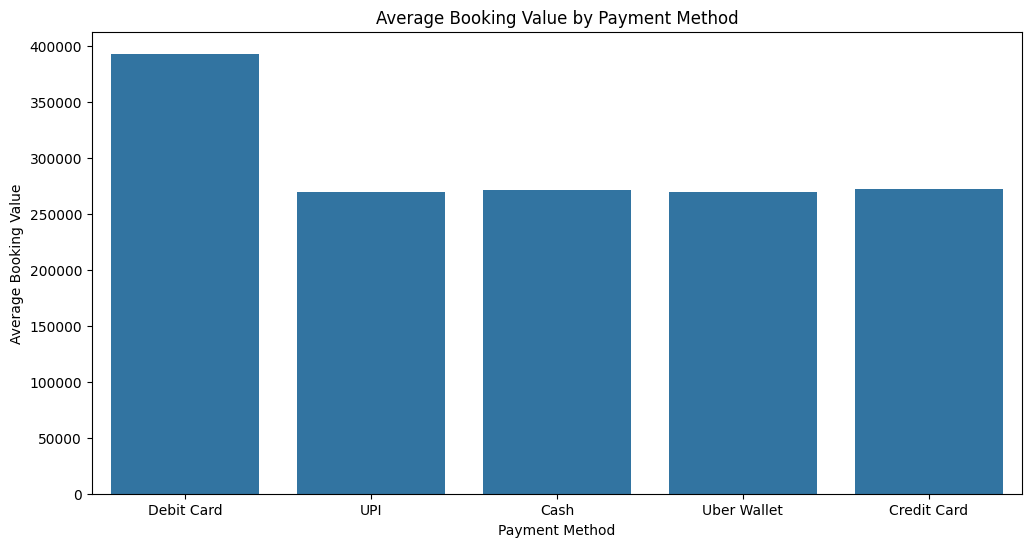

In [ ]:
# create barplot for Booking Value vs Payment Method
plt.figure(figsize=(12, 6))
sns.barplot(x='Payment Method', y='Booking Value', data=df, ci=None)
plt.title('Average Booking Value by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Average Booking Value')
plt.show()

In [ ]:
cm = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

ValueError: could not convert string to float: '2024-03-23'